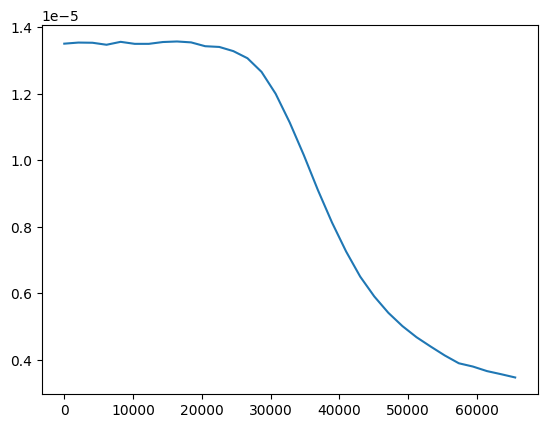

In [7]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('calib_checkerboard_period4.csv', delimiter=',').T
plt.plot(g, p)
plt.show()

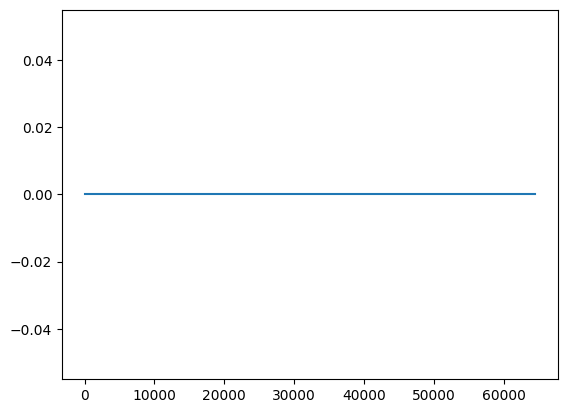

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('ramp_calib_h_p6.csv', delimiter=',').T
plt.plot(g, p)
plt.show()

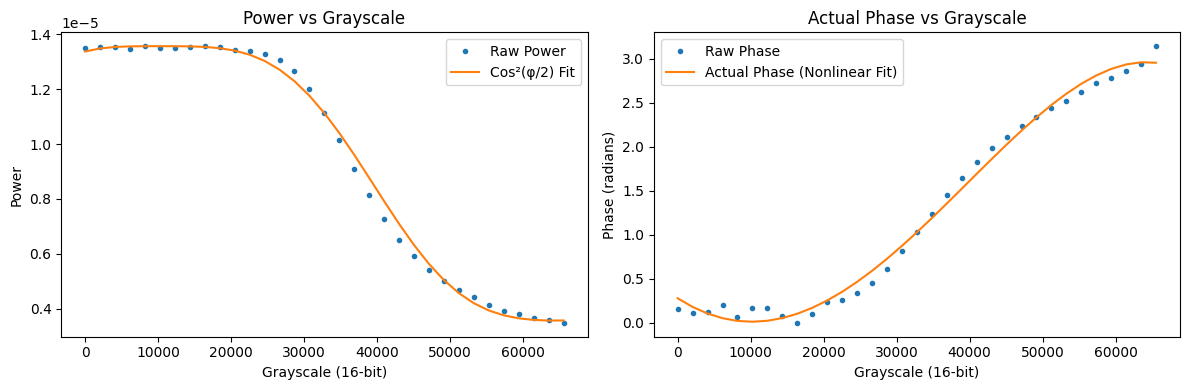

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Load data (Assumes Col 0: 16-bit Grayscale, Col 1: Power)
g, p = np.loadtxt('calib_checkerboard_period4.csv', delimiter=',').T

# 2. Normalize power and calculate raw phase: P ∝ cos²(φ/2) -> φ = 2*arccos(√P_norm)
p_norm = np.clip((p - p.min()) / (p.max() - p.min()), 0, 1)
phi_raw = 2 * np.arccos(np.sqrt(p_norm))

# 3. Unwrap phase (min power is the turning point at π)
phi_raw[np.argmin(p):] = 2 * np.pi - phi_raw[np.argmin(p):]

# 4. Smooth the actual phase vs grayscale relationship (4th order polynomial)
phi_smooth = np.polyval(np.polyfit(g, phi_raw, 4), g)

# 5. Generate 16-bit LUT (Phase 0 -> 2π mapped to Grayscale 0 -> 65535)
desired_phases = np.linspace(0, 2 * np.pi, 65536)
lut = np.clip(interp1d(phi_smooth, g, fill_value="extrapolate")(desired_phases), 0, 65535).astype(np.uint16)
np.savetxt("slm_16bit_lut.csv", lut, fmt='%d', header='Grayscale_16bit', comments='')

# 6. Plotting Actual Phase vs 16-bit Grayscale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(g, p, '.', label='Raw Power')
ax1.plot(g, p.min() + (p.max() - p.min()) * np.cos(phi_smooth/2)**2, '-', label='Cos²(φ/2) Fit')
ax1.set(xlabel='Grayscale (16-bit)', ylabel='Power', title='Power vs Grayscale')
ax1.legend()

ax2.plot(g, phi_raw, '.', label='Raw Phase')
ax2.plot(g, phi_smooth, '-', label='Actual Phase (Nonlinear Fit)')
ax2.set(xlabel='Grayscale (16-bit)', ylabel='Phase (radians)', title='Actual Phase vs Grayscale')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Load data (assuming columns 0 and 1 are gray and power)
g, p = pd.read_csv('calib_checkerboard_period4.csv').values.T

# 2. Define model: P = A * cos^2(phi/2), where phi is a polynomial
def model(g, A, c1, c2, c3):
    return A * np.cos((c1*g + c2*g**2 + c3*g**3) / 2)**2

# 3. Fit the model (Initial guess: A = max power, linear phase slope)
popt, _ = curve_fit(model, g, p, p0=[p.max(), 0.01, 0, 0])

# 4. Extract the fitted phase
fitted_phase = popt[1]*g + popt[2]*g**2 + popt[3]*g**3

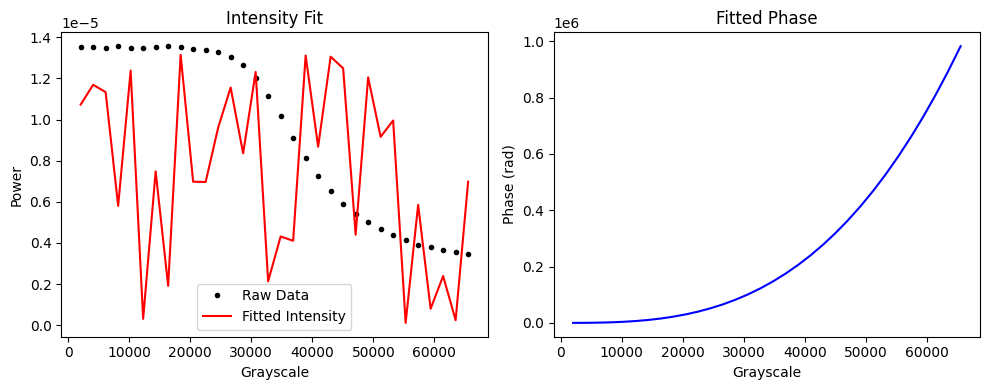

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Intensity plot
ax1.plot(g, p, 'k.', label='Raw Data')
ax1.plot(g, model(g, *popt), 'r-', label='Fitted Intensity')
ax1.set(xlabel='Grayscale', ylabel='Power', title='Intensity Fit')
ax1.legend()

# Phase plot
ax2.plot(g, fitted_phase, 'b-')
ax2.set(xlabel='Grayscale', ylabel='Phase (rad)', title='Fitted Phase')

plt.tight_layout()
plt.show()

